## 1. Загрузка исходных данных и анализ их сырого состояния (Этапы 1.3.1 - 1.3.3)
В этой ячейке мы загружаем часть сырого датасета (чтобы не перегружать память), смотрим на изначальные распределения сумм в долларах, проверяем пропуски и сырые классы транзакций.

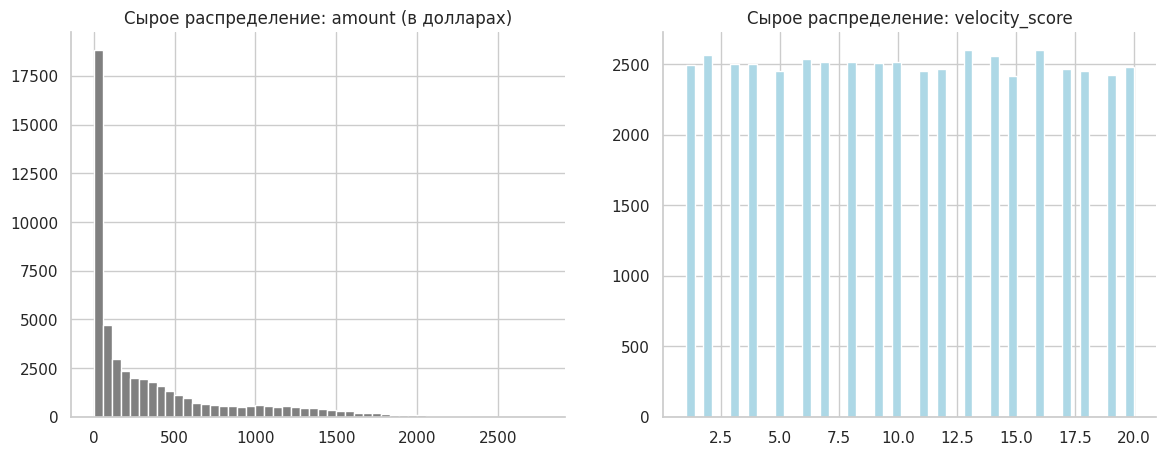

/tmp/ipykernel_1322/3390678414.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df_raw, x='transaction_type', y='amount', palette='pastel')


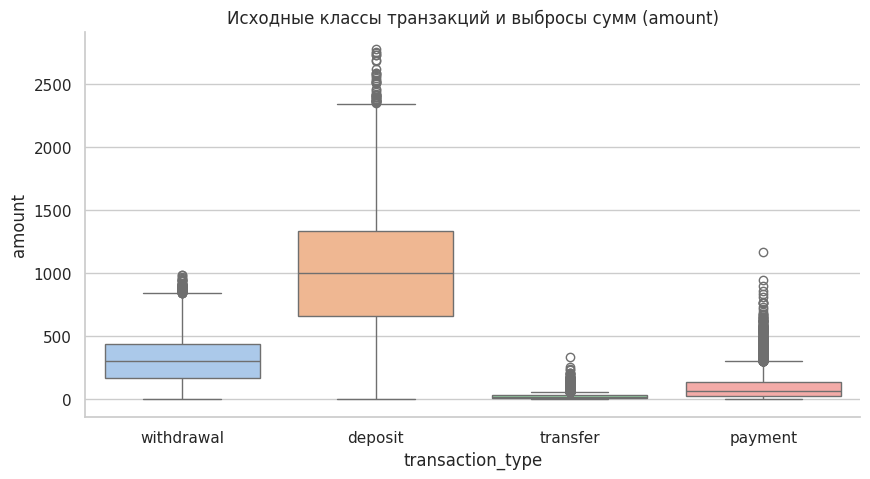

АНАЛИЗ ПРОПУСКОВ
amount                             0
transaction_type                   0
location                           0
time_since_last_transaction    48620
velocity_score                     0
dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Загружаем сырые данные (берем 50 000 строк для анализа сырого состояния)
df_raw = pd.read_csv('/content/drive/MyDrive/financial_fraud_detection_dataset.csv', nrows=50000)

# 1.3.1 ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_raw['amount'], bins=50, color='gray', edgecolor='white')
axes[0].set_title('Сырое распределение: amount (в долларах)')

axes[1].hist(df_raw['velocity_score'], bins=50, color='lightblue', edgecolor='white')
axes[1].set_title('Сырое распределение: velocity_score')
plt.show()

# 1.3.2 ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ
plt.figure(figsize=(10, 5))
sb.boxplot(data=df_raw, x='transaction_type', y='amount', palette='pastel')
plt.title('Исходные классы транзакций и выбросы сумм (amount)')
plt.show()

# 1.3.2 АНАЛИЗ ПРОПУСКОВ
print("АНАЛИЗ ПРОПУСКОВ")
print(df_raw[['amount', 'transaction_type', 'location', 'time_since_last_transaction','velocity_score']].isnull().sum())

## 2. Корреляции и Дубликаты сырых данных (Этапы 1.3.4 - 1.3.6)
Проверка сырых числовых скорингов на корреляцию и поиск дубликатов перед трансфигурацией.

УСТРАНЕНИЕ ДУБЛИКАТОВ
Полных дубликатов в сыром массиве: 0

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


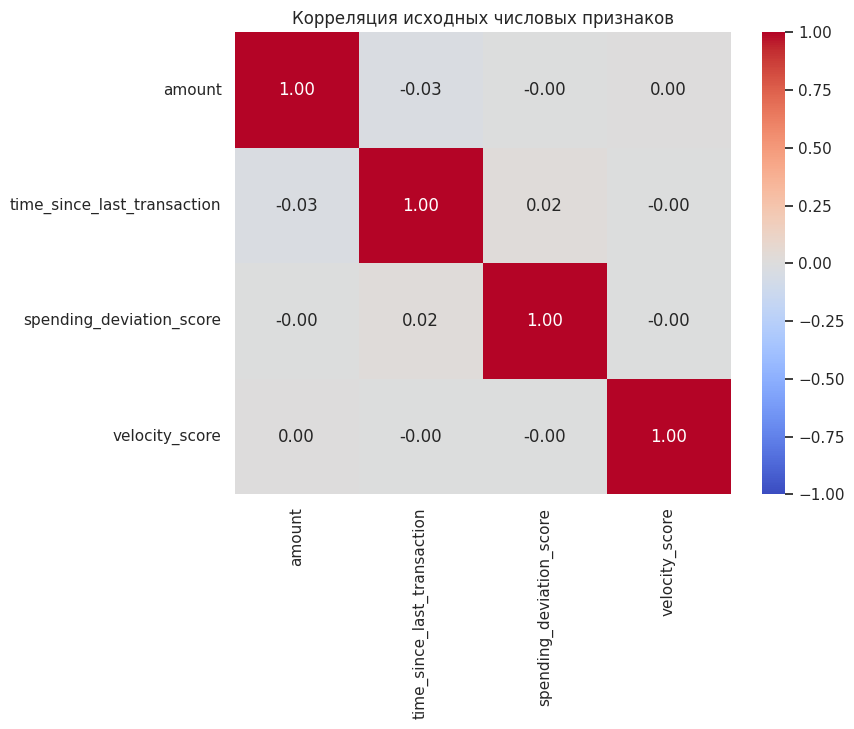

In [ ]:
print("УСТРАНЕНИЕ ДУБЛИКАТОВ")
print(f"Полных дубликатов в сыром массиве: {df_raw.duplicated().sum()}")

print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
raw_numeric = df_raw[['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score']]

plt.figure(figsize=(8, 6))
sb.heatmap(raw_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Корреляция исходных числовых признаков')
plt.show()

## 3. Форматирование данных под задачу (Этап 1.3.7)
Выполняется фильтрация сырого массива: удаление фрода и лишних классов. Для формирования рабочей выборки отбираются транзакции 750 активных клиентов, что дает репрезентативный массив объемом около 5000 строк с сохранением хронологии операций. Формируются новые признаки, локализуются геометки, а время суток извлекается в формате точного часа (от 0 до 23). Суммы переводятся в рубли с применением банковской логики округления.

In [ ]:
# Загружаем полный датасет
use_cols = ['timestamp', 'sender_account', 'amount', 'transaction_type', 'location',
            'payment_channel', 'spending_deviation_score', 'velocity_score', 'is_fraud']
df_full = pd.read_csv('/content/drive/MyDrive/financial_fraud_detection_dataset.csv', usecols=use_cols)

# 1. Отсекаем фрод
df_clean = df_full[df_full['is_fraud'] == 0].copy()

# 2. Маппинг целевой переменной
target_mapping = {
    'payment': 'Оплата', 'purchase': 'Оплата', 'pos': 'Оплата',
    'transfer': 'Перевод', 'peer-to-peer': 'Перевод',
    'withdrawal': 'Снятие', 'cash_out': 'Снятие', 'atm': 'Снятие'
}
df_clean['temp_type'] = df_clean['transaction_type'].astype(str).str.lower()
df_clean['Категория_транзакции'] = df_clean['temp_type'].map(target_mapping)
df_clean = df_clean.dropna(subset=['Категория_транзакции'])

# 3. Выборка активных клиентов (1000 клиентов)
account_counts = df_clean['sender_account'].value_counts()
active_accounts = account_counts[(account_counts >= 3) & (account_counts <= 15)].index
np.random.seed(42)
sampled_accounts = np.random.choice(active_accounts, size=1000, replace=False)
df_final = df_clean[df_clean['sender_account'].isin(sampled_accounts)].copy()

# 4. Временные признаки, предыдущие операции и время с прошлой операции
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'], format='mixed', errors='coerce')
df_final = df_final.sort_values(by=['sender_account', 'timestamp'])

df_final['Предыдущие_транзакции'] = df_final.groupby('sender_account').cumcount()

# Вычисляем разницу во времени с предыдущей строкой
df_final['Время_с_прошлой_операции'] = df_final.groupby('sender_account')['timestamp'].diff().dt.total_seconds() / 3600
# Для первой транзакции разница будет NaN, заменяем на 0 и округляем
df_final['Время_с_прошлой_операции'] = df_final['Время_с_прошлой_операции'].fillna(0).round(1)

# Извлекаем часы и дни недели
df_final['Время_суток'] = df_final['timestamp'].dt.hour
df_final['День_недели'] = df_final['timestamp'].dt.day_name().map({
    'Monday': 'Понедельник', 'Tuesday': 'Вторник', 'Wednesday': 'Среда',
    'Thursday': 'Четверг', 'Friday': 'Пятница', 'Saturday': 'Суббота', 'Sunday': 'Воскресенье'
})

# 5. Локализация и тип счета
russian_cities = [
    'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань',
    'Нижний Новгород', 'Красноярск', 'Челябинск', 'Самара', 'Уфа',
    'Ростов-на-Дону', 'Краснодар', 'Омск', 'Воронеж', 'Пермь',
    'Волгоград', 'Саратов', 'Тюмень', 'Тольятти', 'Махачкала'
    ]
top_cities = df_final['location'].value_counts().nlargest(len(russian_cities)).index.tolist()
df_final['Местоположение'] = df_final['location'].map(dict(zip(top_cities, russian_cities))).fillna('Онлайн')

def determine_account_type(row):
    ch, txn = str(row['payment_channel']).lower(), str(row['temp_type']).lower()
    if ch in ['ach', 'wire_transfer', 'upi']: return 'Дебетовый'
    if ch == 'card': return 'Дебетовый' if txn in ['withdrawal', 'atm', 'cash_out'] else 'Кредитный'
    return 'Дебетовый'
df_final['Тип_счета'] = df_final.apply(determine_account_type, axis=1)

# 6. Суммы в рублях и бизнес-логика округления
df_final['Сумма_транзакции'] = (df_final['amount'] * 90.0).round(0)

mask_w = df_final['Категория_транзакции'] == 'Снятие'
df_final.loc[mask_w, 'Сумма_транзакции'] = (df_final.loc[mask_w, 'Сумма_транзакции'] / 100).round() * 100
df_final.loc[mask_w & (df_final['Сумма_транзакции'] > 3000), 'Сумма_транзакции'] = (df_final.loc[mask_w & (df_final['Сумма_транзакции'] > 3000), 'Сумма_транзакции'] / 500).round() * 500
df_final.loc[mask_w & (df_final['Сумма_транзакции'] < 100), 'Сумма_транзакции'] = 100

mask_t = df_final['Категория_транзакции'] == 'Перевод'
df_final.loc[mask_t & (df_final['Сумма_транзакции'] < 1000), 'Сумма_транзакции'] = (df_final.loc[mask_t & (df_final['Сумма_транзакции'] < 1000), 'Сумма_транзакции'] / 50).round() * 50
df_final.loc[mask_t & (df_final['Сумма_транзакции'] >= 1000), 'Сумма_транзакции'] = (df_final.loc[mask_t & (df_final['Сумма_транзакции'] >= 1000), 'Сумма_транзакции'] / 100).round() * 100

p95 = df_final['Сумма_транзакции'].quantile(0.95)
df_final['Сумма_транзакции'] = df_final['Сумма_транзакции'].clip(upper=p95)

# 7. Финальная сборка 10 признаков
df_final['Отклонение_расходов'] = df_final['spending_deviation_score'].round(2)
df_final['Скорость_транзакций'] = df_final['velocity_score'].round(2)

final_columns = ['Сумма_транзакции', 'Время_с_прошлой_операции', 'Отклонение_расходов', 'Скорость_транзакций', 'Предыдущие_транзакции', 'Время_суток', 'День_недели', 'Тип_счета', 'Местоположение', 'Категория_транзакции']
df_transformed = df_final[final_columns].reset_index(drop=True)

print(f"Итоговый объем выборки: {len(df_transformed)} строк.")
display(df_transformed.head(10))

Итоговый объем выборки: 4701 строк.


,Сумма_транзакции,Время_с_прошлой_операции,Отклонение_расходов,Скорость_транзакций,Предыдущие_транзакции,Время_суток,День_недели,Тип_счета,Местоположение,Категория_транзакции
0,2564.0,0.0,-0.03,19,0,23,Понедельник,Дебетовый,Красноярск,Оплата
1,32500.0,3054.9,-1.88,20,1,6,Среда,Дебетовый,Нижний Новгород,Снятие
2,2351.0,637.0,-0.79,3,2,19,Понедельник,Дебетовый,Екатеринбург,Оплата
3,21000.0,0.0,0.61,7,0,1,Суббота,Дебетовый,Казань,Снятие
4,2107.0,1209.5,1.37,16,1,10,Воскресенье,Дебетовый,Красноярск,Оплата
5,1600.0,4912.1,0.70,18,2,2,Вторник,Дебетовый,Казань,Перевод
6,38000.0,1006.7,-0.36,10,3,1,Вторник,Дебетовый,Новосибирск,Снятие
7,800.0,0.0,-0.29,8,0,17,Суббота,Дебетовый,Нижний Новгород,Перевод
8,2200.0,714.1,-1.27,7,1,11,Понедельник,Кредитный,Красноярск,Перевод
9,24000.0,607.1,-1.40,2,2,18,Пятница,Дебетовый,Екатеринбург,Снятие
